#### House price prediction on dataset from kaggle
##### https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview/tutorials

In [1]:
# Features -- atributes/columns names simply said
# Target variables --
# Dependent variables --- ??
# Independant variables --- ??
# output feature --- if something we need to clasify, to predict

In [2]:
# importing lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import xgboost as xgb
import os
import kaggle
os.environ['KAGGLE_USERNAME'] = "pyninad90"
os.environ['KAGGLE_KEY'] = "KGAT_ed4011a1fdab61a63c5fcbac05284de4"

# setting plot style beforehand
sns.set_style("whitegrid")

In [3]:
# downloading data from kaggle website using API
# go to kaggle account > settings > generate new token > 
# KGAT_ed4011a1fdab61a63c5fcbac05284de4

In [4]:
df = pd.read_csv("Datasets/house-prices-advanced-regression-techniques/test.csv")

In [5]:
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [6]:
df.tail(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [7]:
train_df = pd.read_csv('Datasets/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('Datasets/house-prices-advanced-regression-techniques/test.csv')

# setting id column as index for constistancy
train_df.set_index("Id",inplace=True)
test_df.set_index("Id",inplace=True)

print("train_df shape",train_df.shape)
print("test_df shape", test_df.shape)

train_df shape (1460, 80)
test_df shape (1459, 79)


In [8]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


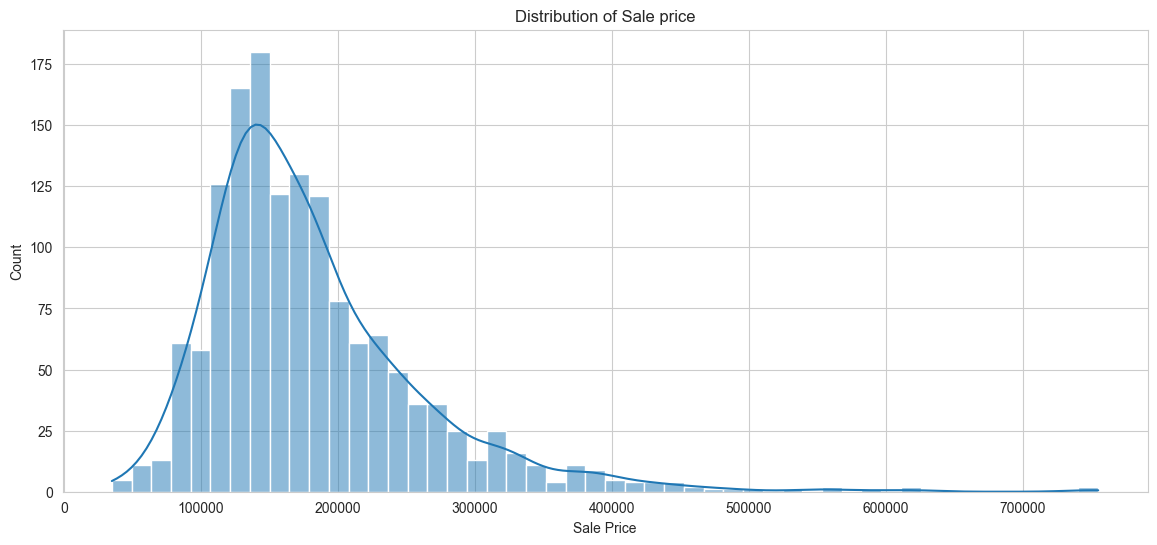

1.8828757597682129


In [9]:
plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde=True,bins=50)
plt.title('Distribution of Sale price')
plt.xlabel('Sale Price')
plt.show()

print(train_df['SalePrice'].skew())

In [10]:
print(np.log(100))
print(np.log(1000))
print(np.log(10000))
print(np.log(1000000))
print(np.log(1000000000))

4.605170185988092
6.907755278982137
9.210340371976184
13.815510557964274
20.72326583694641


In [11]:
train_df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


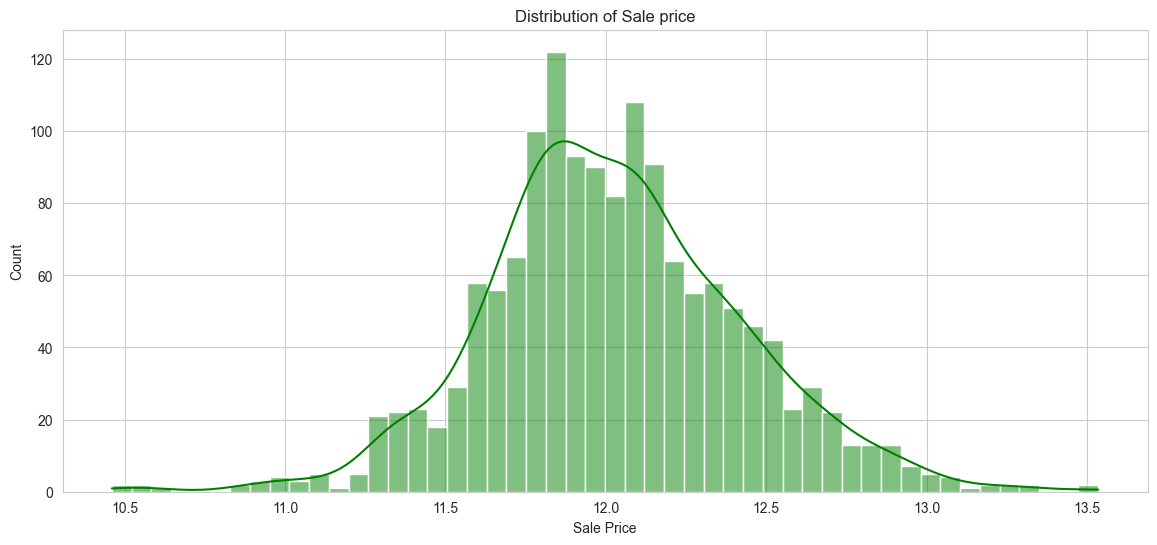

Skewness: 0.12134661989685333


In [12]:
# doing below line to get the normal distribution values in SalePrice column b'coz we need to pass this to linear regression model which doesnt work well with skewed data see cell 16 but works well with
# normal distrubution

train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde=True,bins=50,color='green')
plt.title('Distribution of Sale price')
plt.xlabel('Sale Price')
plt.show()

print('Skewness:',train_df['SalePrice'].skew())

In [13]:
train_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171


#### 4.EDA on feature variables

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')


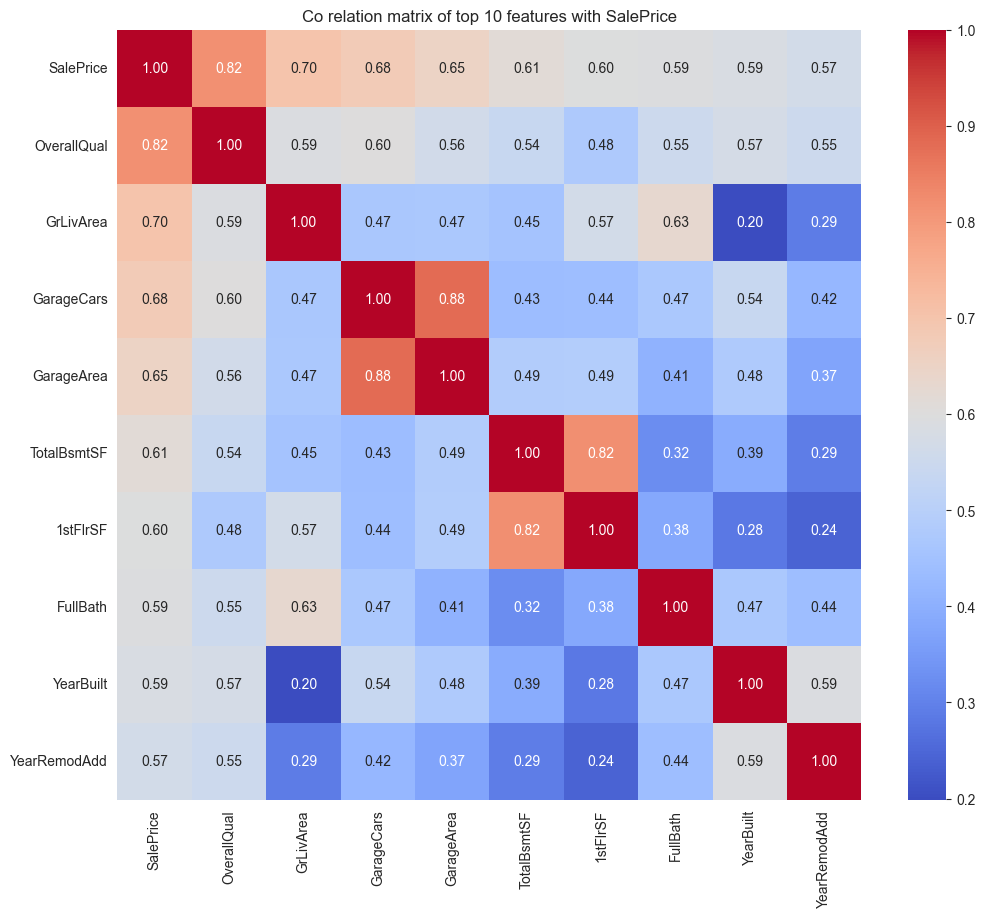

In [14]:
corrmat = train_df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10,columns="SalePrice")["SalePrice"].index
print(top_corr_features)
top_corr_matrix = train_df[top_corr_features].corr()
top_corr_matrix

plt.figure(figsize=(12,10))
sns.heatmap(top_corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Co relation matrix of top 10 features with SalePrice')
plt.show()

#### 5.Data Preprocessing and Feature engineering

In [15]:
# in this part we will handle missing values,create new features,encode categorical variables to prepare data for modeling (to feed data to model)

In [16]:
train_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171


In [17]:
test_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [18]:
all_data = pd.concat((train_df.loc[:,:'SaleCondition'],test_df.loc[:,:'SaleCondition']))
print(all_data)

      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                      
1             60       RL         65.0     8450   Pave   NaN      Reg   
2             20       RL         80.0     9600   Pave   NaN      Reg   
3             60       RL         68.0    11250   Pave   NaN      IR1   
4             70       RL         60.0     9550   Pave   NaN      IR1   
5             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
2915         160       RM         21.0     1936   Pave   NaN      Reg   
2916         160       RM         21.0     1894   Pave   NaN      Reg   
2917          20       RL        160.0    20000   Pave   NaN      Reg   
2918          85       RL         62.0    10441   Pave   NaN      Reg   
2919          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... ScreenPo

In [19]:
# this way it make sure that both training and testing dataset have consistantly preprocesing steps applied on them like handling null values and encoding categorical columns
# which prevents data leakage and potential data issues during while modeling process.

##### 5.1 Handling missing values

In [20]:
missing_data = all_data.isna().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

print(missing_data)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageFinish     159
GarageYrBlt      159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Functional         2
BsmtFullBath       2
Utilities          2
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF1         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
BsmtFinSF2         1
dtype: int64


In [21]:
numerical_cols_to_impute_zero = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'BsmtFullBath', 'BsmtHalfBath']
for col in numerical_cols_to_impute_zero:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

In [22]:
all_data[numerical_cols_to_impute_zero].isna().sum()

MasVnrArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
GarageCars      0
GarageArea      0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

In [23]:
all_data['LotFrontage'].value_counts()

LotFrontage
60.0     276
80.0     137
70.0     133
50.0     117
75.0     105
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 128, dtype: int64

In [24]:
if 'LotFrontage' in all_data.columns and all_data['LotFrontage'].isna().any():
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [25]:
# Impute categorical features with 'None' (for features where NA means 'no') or mode (for features where NA means missing data)
categorical_cols_to_impute_none = ['Alley', 'Fence', 'MiscFeature', 'PoolQC', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in categorical_cols_to_impute_none:
    if col in all_data.columns: # Check if column exists after one-hot encoding
        all_data[col] = all_data[col].fillna('None')

# applying mode below because it is categorical column 
for col in ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Utilities', 'Functional', 'MSZoning']:
    if col in all_data.columns: # Check if column exists after one-hot encoding
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [26]:
# Based on the likely remaining missing values (GarageYrBlt), impute the remaining numerical features.
# GarageYrBlt can be imputed with 0 (assuming 0 means no garage, consistent with GarageArea/Cars=0)
if 'GarageYrBlt' in all_data.columns:
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)


print("\nMissing values after all imputation:", all_data.isna().sum().sum())


Missing values after all imputation: 0


##### 5.2 Feature Engineering

In [27]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Create a total bathrooms feature
all_data['TotalBath'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                         all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

# Create a feature for age of the house at sale
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']

print("New features created.")

New features created.


##### What is label encoding and what is one-hot encoding?

In [28]:
# label encoding have inherient order for them eg Poor > Fair > Good > Excellent for these i can order it like poor = 0 and fair = 1 and good = 2 and excellent = 3
# one-hot encoding have no inherint order for them eg neighbourhood in this dataset. which creates new binary columns ie 0/1 for each category see below

In [34]:
all_data.columns
all_data["Neighborhood"]
# here there is no perticular order for this neighborhood data hence we would use one-hot encoding

Id
1       CollgCr
2       Veenker
3       CollgCr
4       Crawfor
5       NoRidge
         ...   
2915    MeadowV
2916    MeadowV
2917    Mitchel
2918    Mitchel
2919    Mitchel
Name: Neighborhood, Length: 2919, dtype: object

In [38]:
categorical_col = all_data.select_dtypes(include=["object"]).columns
all_data = pd.get_dummies(data=all_data,columns=categorical_col,drop_first=True)
# here basically pd.get_dummies is doing one hot encoding
print(all_data.shape)

(2919, 262)


#### 6.Model Building & Training.

In [39]:
# now separating preprocessed data back into training and testing set
X = all_data[:len(train_df)]
y = train_df['SalePrice']
X_test_final = all_data[len(train_df):]

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size= 0.2,random_state=42) # PRNG what is this PRNG?

In [40]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(1168, 262)
(292, 262)
(1168,)
(292,)


In [41]:
# What is standard scaler ? standard deviation ? 

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_final_scaled = scaler.transform(X_test_final)

#### 6.1 Model 1:Linear Regression (Baseline)

In [47]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred_lr = lr.predict(X_val_scaled)
print(y_pred_lr)

[11.94136732 12.73981795 11.51734525 12.01487948 12.64926257 11.28125177
 12.42367424 11.89852165 11.22643455 11.86994258 11.88608842 11.64392657
 11.23230401 12.26138536 12.07110195 11.80087308 12.14706831 11.78972384
 11.58284822 12.2693948  11.92793845 12.22406554 12.07011723 11.82560994
 12.19616524 11.89526696 12.15166979 11.60271912 12.10684603 12.1969508
 12.08657634 12.53744901 12.30214298 11.66556937 12.45474616 11.93105985
 11.89189847 12.19935819 12.68351764 11.58686028 11.80931906 12.29662339
 11.60207364 12.82646513 11.75787557 11.74918942 11.57708431 11.81620749
 13.04562787 11.8267837  11.7062313  12.24629524 11.5574877  12.6258775
 12.0258037  12.38911243 12.22142841 11.95688407 11.78095167 11.50236687
 11.30197603 11.9977707  12.64750084 12.40696689 12.60854943 12.19663563
 11.60748068 12.68077664 11.77433401 12.06892974 11.69741112 11.73775263
 11.63026763 11.24470796 13.12337995 12.12679992 12.63017672 12.6807212
 11.92065947 11.72093047 11.64806817 11.35321123 11.62

In [52]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-squared: {r2:.4f}\n")

evaluate_model(y_val, y_pred_lr, "Linear Regression")

--- Linear Regression Performance ---
RMSE: 0.1734
MAE:  0.0960
R-squared: 0.8389



In [48]:
xgbr = xgb.XGBRegressor(objective='reg:squarederror', # Corrected objective function
                        n_estimators=1000,
                        learning_rate=0.05,
                        max_depth=3,
                        min_child_weight=1,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42)

# XGBoost can handle NaNs, but since we've cleaned the data, we can use the scaled data as well if preferred.
# However, XGBoost generally doesn't require scaling. We'll use the unscaled data as it's a tree-based model.
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_val)

##### 7.Model Evaluation

In [50]:
# Learn more about regression metrics
# Mean Absolute Error (MAE)
# Mean Squared Error (MSE)\
# Root Mean Squared Error (RMSE)
# R-Squared (R^2)

In [51]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-squared: {r2:.4f}\n")

# evaluate_model(y_val, y_pred_lr, "Linear Regression") # Commenting out Linear Regression evaluation as it failed
evaluate_model(y_val, y_pred_xgb, "XGBoost")

--- XGBoost Performance ---
RMSE: 0.1344
MAE:  0.0864
R-squared: 0.9032



In [53]:
# Make predictions on the final test set using the best model (XGBoost)
# Use the unscaled test data for XGBoost prediction
final_predictions_log = xgbr.predict(X_test_final)

# IMPORTANT: We must reverse the log transformation to get the predictions back on the original price scale
final_predictions = np.expm1(final_predictions_log)

# Create the submission DataFrame
submission = pd.DataFrame({'Id': test_df.index, 'SalePrice': final_predictions})

# Save to csv
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
submission.head()

Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,123225.789062
1,1462,163591.781250
2,1463,190166.703125
3,1464,194260.031250
4,1465,182331.875000
